# Homework

Suppose the globe tossing data had turned out to be 3 water and 11 land. 

1. Construct the posterior distribution. 
2. Then using the posterior distribution, compute the posterior predictive distribution for the next 5 tosses of the same globe.

---

#### Q1. Construct the posterior distribution

In [1]:
WATER = 3
LAND = 11
TOTAL = 14

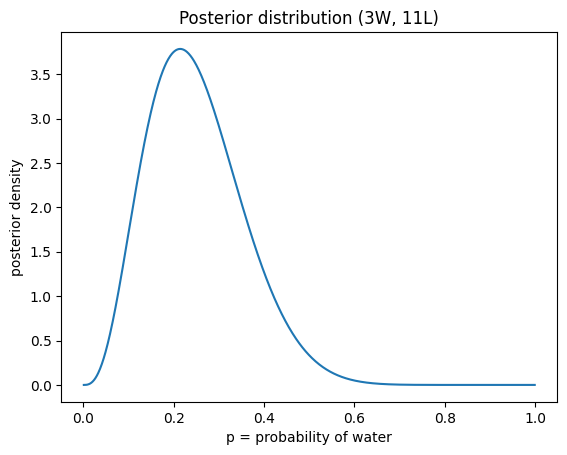

In [3]:
import math
import matplotlib.pyplot as plt

ALPHA = WATER + 1
BETA = LAND + 1

def beta_probability_density(p, alpha, beta):
    # Beta density:
    # p^(alpha-1) * (1-p)^(beta-1) / B(alpha, beta)
    log_B = math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)
    return math.exp((alpha - 1) * math.log(p) + (beta - 1) * math.log(1 - p) - log_B)

# avoid exactly 0 and 1 because log(0) is undefined
p_grid = [i / 1000 for i in range(1, 1000)]
posterior = [beta_probability_density(p, ALPHA, BETA) for p in p_grid]

plt.plot(p_grid, posterior)
plt.xlabel("p = probability of water")
plt.ylabel("posterior density")
plt.title("Posterior distribution (3W, 11L)")
plt.show()

#### Q2. Compute the posterior predictive distribution for the next 5 tosses

{0: 0.2801, 1: 0.3501, 2: 0.2358, 3: 0.1004, 4: 0.0297, 5: 0.0039}


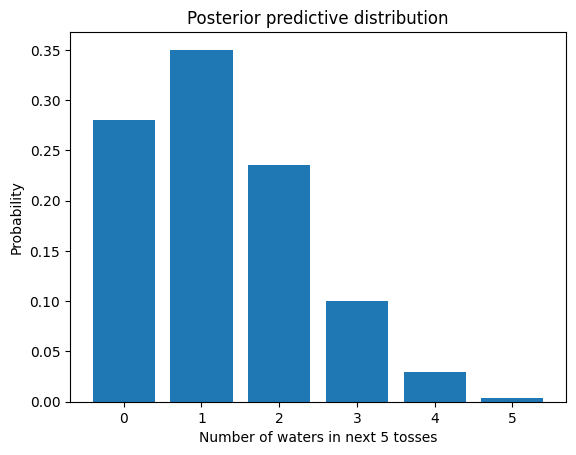

In [4]:
import random

n_simulations = 10_000
n_tosses = 5
results = []

for _ in range(n_simulations):
    # Step 1: draw one possible value of p from the posterior
    p = random.betavariate(ALPHA, BETA)

    # Step 2: use that p to simulate 5 future tosses
    waters = 0

    for _ in range(n_tosses):
        toss = random.random()
        if toss < p:
            waters += 1

    results.append(waters)

# Count how often each outcome happened
counts = {}

for k in range(n_tosses + 1):
    counts[k] = results.count(k)

# Convert counts to probabilities
probabilities = {}

for k in counts:
    probabilities[k] = counts[k] / n_simulations

print(probabilities)
plt.bar(probabilities.keys(), probabilities.values())
plt.xlabel("Number of waters in next 5 tosses")
plt.ylabel("Probability")
plt.title("Posterior predictive distribution")
plt.xticks(range(n_tosses + 1))
plt.show()